# Trust and serve: explaining a TFM's predictions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Innixma/kdd2026_tutorial_materials/blob/main/notebooks/07_interpretability.ipynb)
[![GitHub Repo](https://img.shields.io/badge/GitHub-Repo-181717?logo=github)](https://github.com/Innixma/kdd2026_tutorial_materials)
[![Tutorial Website](https://img.shields.io/badge/Tutorial-Website-0a7aca?logo=googlechrome&logoColor=white)](https://kdd26-automl-hands-on.github.io/)

**Taming Structured Data Foundation Models with AutoML — KDD 2026 hands-on tutorial**

"Foundation models are black boxes" is the objection this notebook retires. TabPFN ships
first-class interpretability through [shapiq](https://github.com/mmschlk/shapiq) Shapley
values (the pattern below is adapted from the
[official TabPFN demo](https://github.com/PriorLabs/TabPFN/blob/main/examples/notebooks/TabPFN_Demo_Local.ipynb)),
and we apply it to the bankruptcy predictions from notebooks 01-02: *which financial
ratios made the model flag this company?*

Along the way we meet the serving-side feature that makes explanation workloads practical:
`fit_mode` — an in-context model's "fit" is really the encoding of its training context,
and caching that encoding makes every subsequent `predict` call much faster. Explanations
issue *many* such calls.

> **Runtime**: ~5 minutes on a Colab T4. Uses [TabPFN-3](https://priorlabs.ai/technical-reports/tabpfn-3)
> locally (gated checkpoint, token below).

## Setup

In [1]:
import sys
!command -v uv >/dev/null || pip install -q uv
!uv pip install -q --python {sys.executable} tabpfn tabpfn-extensions shapiq openml

# The install may replace Colab's preinstalled numpy; the copy already loaded in this
# kernel then no longer matches the files on disk and imports break. When that happens,
# restart the runtime once (continue from the next cell after it reconnects).
import importlib.metadata
import numpy
if importlib.metadata.version("numpy") != numpy.__version__:
    print("numpy changed -- restarting the Colab runtime; re-run FROM THE NEXT CELL when it reconnects.")
    import os
    os.kill(os.getpid(), 9)

## The dataset

Split 0 of *polish_companies_bankruptcy*, as in notebooks 01 and 02 — 64 named financial ratios, which is what makes the explanations legible.

In [2]:
import os

import openml

# Temporary tutorial token for the gated TabPFN-3 checkpoint (revoked after KDD 2026).
# Get a free personal token at https://priorlabs.ai and use it instead after the session.
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_urveJ352tgTRgaE-v2q1ghl5ZF86DVdhbEJAkzkZea4"

task = openml.tasks.get_task(363694)  # polish_companies_bankruptcy
X, y = task.get_X_and_y(dataset_format="dataframe")
y = (y == y.cat.categories[1]).astype(int) if hasattr(y, "cat") else y.astype(int)
train_idx, test_idx = task.get_train_test_split_indices(repeat=0, fold=0)

feature_names = list(X.columns)
X_train, y_train = X.iloc[train_idx].to_numpy(), y.iloc[train_idx].to_numpy()
X_test, y_test = X.iloc[test_idx].to_numpy(), y.iloc[test_idx].to_numpy()
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (3940, 64), test: (1970, 64)


## The fit-mode story

For an in-context model, `fit` is really the one-time encoding of the training context —
and `fit_mode` decides whether that work is cached or redone on every `predict`:

- `"low_memory"` — re-process the context on demand at each predict (cheapest memory).
- `"fit_with_cache"` — build the context representation once at fit and reuse it (the
  KV-cache pattern), making repeated inference much faster.

We time twenty predict calls under each mode:

In [3]:
import time

from tabpfn_extensions import TabPFNClassifier

# Untimed warm-up: downloads the checkpoint and initializes CUDA once, so the
# timings below compare the fit modes rather than one-time setup cost.
TabPFNClassifier(
    model_path="tabpfn-v3-classifier-v3_default.ckpt", n_estimators=1
).fit(X_train, y_train).predict_proba(X_test[:25])

for mode in ["low_memory", "fit_with_cache"]:
    clf = TabPFNClassifier(
        model_path="tabpfn-v3-classifier-v3_default.ckpt", fit_mode=mode, n_estimators=1
    )
    t0 = time.time()
    clf.fit(X_train, y_train)
    fit_s = time.time() - t0
    t0 = time.time()
    for _ in range(20):
        clf.predict_proba(X_test[:25])
    print(f"{mode:>15s}: fit {fit_s:.1f}s | 20 predict calls {time.time() - t0:.1f}s")

/home/nick_priorlabs_ai/workspace_tabpfn_plus/venv/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/nick_priorlabs_ai/workspace_tabpfn_plus/venv/.venv/lib/python3.11/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


     low_memory: fit 0.4s | 20 predict calls 2.0s


 fit_with_cache: fit 0.4s | 20 predict calls 0.5s


Similar fit cost, several times faster predicts — and the gap widens with context size and
`n_estimators`. That is exactly the right trade for serving, for what-if analysis, and for
the Shapley computation next, which issues hundreds of predict calls against the same
fitted context.

## Which ratios flagged this company?

shapiq's imputation-based explainer computes Shapley values per prediction. We keep the
cached classifier from above, explain the five test companies the model considers riskiest,
and read the answer in named financial ratios.

In [4]:
import numpy as np
import shapiq
from tabpfn_extensions.interpretability import shapiq as tabpfn_shapiq

# clf still holds the cached fit from the timing cell.
proba = clf.predict_proba(X_test)[:, 1]
riskiest = np.argsort(proba)[::-1][:5]
print("predicted bankruptcy probability of the 5 riskiest companies:", proba[riskiest].round(3))

explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
    model=clf,
    data=X_train,
    index="SV",          # plain Shapley values, like classic SHAP
    max_order=1,         # SV has no interaction terms
    imputer="baseline",  # good speed/quality trade-off, per the official demo
)
shapley_values = [explainer.explain(x=X_test[i], budget=256) for i in riskiest]

predicted bankruptcy probability of the 5 riskiest companies: [1. 1. 1. 1. 1.]


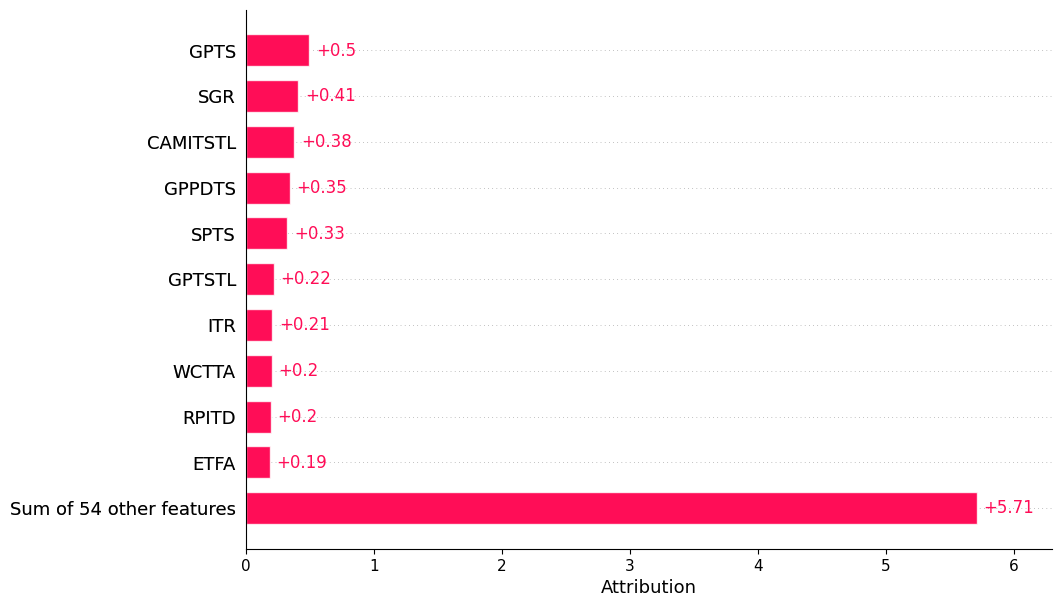

In [5]:
# Aggregate importances across the five riskiest companies...
shapiq.plot.bar_plot(shapley_values, feature_names=feature_names, show=True)

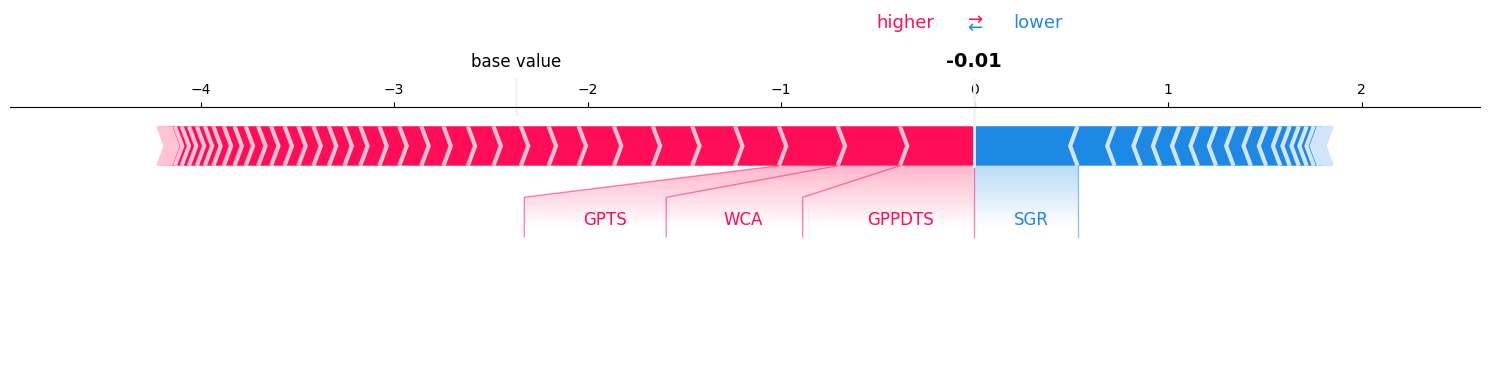

In [6]:
# ...and the single riskiest one: how each ratio pushes its prediction toward bankruptcy.
shapley_values[0].plot_force(feature_names=feature_names)

## What just happened

- **Per-prediction accountability.** Notebook 02 showed *global* permutation importance
  through AutoGluon; this is the per-company complement — for any individual flag, the
  named ratios pushing it, computable on demand.
- **The cache makes it practical.** Explanations, what-if probing, and online serving all
  hammer `predict` against a fixed context; `fit_mode="fit_with_cache"` turns that from the
  expensive path into the fast one.
- **Go further**: the [official demo](https://github.com/PriorLabs/TabPFN/blob/main/examples/notebooks/TabPFN_Demo_Local.ipynb)
  continues with interaction values, embeddings, and decision-boundary visualizations; the
  model itself is described in the [TabPFN-3 technical report](https://priorlabs.ai/technical-reports/tabpfn-3).

**Next**: [notebook 08](https://colab.research.google.com/github/Innixma/kdd2026_tutorial_materials/blob/main/notebooks/08_noniid_validation.ipynb) tackles data where rows aren't IID — honest validation with grouped and temporal splits.